# WIMP Dark Matter in Alternative Cosmologies - Inverse problem

### Imports

In [1]:
import torch
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from pinn import PINN
import utils

### Constants

In [2]:
z0 = utils.Z0
zf = utils.ZF

g = utils.G
g_asts = utils.G_ASTS

w0 = utils.W0
wf = utils.WF

w_n = -wf

C_std = utils.C_STD
C_rs = utils.C_RS
C_gb = utils.C_GB

gamma_std = utils.GAMMA_STD
gamma_rs = utils.GAMMA_RS
gamma_gb = utils.GAMMA_GB

zt1 = utils.ZT1

num_coloc = 1000 # To compare solve_ivp with the PINN, we need the same number of points in both, so we define it here.
cosmology = 'Std'

### Finite element method 

In [3]:
def w_eq_fem(z):
    """
    Computes the equilibrium yield W_eq for the finite element method.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        
    Returns:
        float: The definition of W_eq.
    """
    
    return np.log(45.0 / np.sqrt(32.0 * np.pi**7) * g / g_asts) + 1.5 * z - np.exp(z)

In [4]:
def returns_dwdz(z, w, C, gamma): 
    """
    Computes the derivative of the Boltzmann equation for comparison purposes.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        w (float): The logarithm of Y, the number density of DM.
        C (float): Proxy for the cross-section.
        gamma (float): Power-law parameter.
        
    Returns:
        float: The derivative of the Boltzmann equation.
    """
    dwdz = np.exp(C - gamma * max(0, zt1 - z) - z) * (np.exp(2.0 * w_eq_fem(z) - w) - np.exp(w))
        
    return dwdz

if cosmology == "Std":
    C = C_std
    gamma = gamma_std
elif cosmology == "RS":
    C = C_rs
    gamma = gamma_rs
elif cosmology == "GB":
    C = C_gb
    gamma = gamma_gb
else:
    raise Exception("The only available choices of cosmology are Standard ('Std'), Randall-Sundrum ('RS') and Gauss-Bonnet (GB).")
  
# Time
z = np.linspace(z0, zf, num_coloc) 
  
# ODE solver
fem_sol = solve_ivp(returns_dwdz, [z0, zf], np.array([w0]), method='BDF', args=(C, gamma), dense_output=True, rtol=1e-7, atol=1e-9)

In [5]:
def plotting(C, preds, x_coloc):
    """
    Plots the PINN and FEM solutions of the ODE.

    Parameters:
        C (float): Proxy for the cross-section.
        preds (float): Predictions of the PINN.
        x_coloc (float): Collocation points.
    """

    x_coloc = x_coloc.detach().numpy()
    
    plt.figure(figsize=(10,8))
    plt.plot(x_coloc, preds, 'r', label='PINN')
    plt.plot(fem_sol.t, fem_sol.y.reshape(-1,) / w_n, color='green', linestyle=':', label='Exact solution')
    plt.xlabel(r'$z$') 
    plt.ylabel(r'$W_n$') 
    plt.legend()
    plt.show()

In [6]:
print(fem_sol.y[-1][-1]) # Important to make comparisons between the result provided by the PINN and the one provided by solve_ivp

-26.158508777959046


### W_eq definition for PyTorch

In [7]:
def w_eq(z):
    """
    Computes the equilibrium yield W_eq for PyTorch.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        
    Returns:
        float: The definition of W_eq.
    """
    return torch.log(45.0 / torch.sqrt(torch.tensor(32.0 * np.pi**7)) * g / g_asts) + 1.5 * z - torch.exp(z)

### Training step

In [8]:
normalize_jacobian = True

n_epochs = 200_000
lr = 2.0e-3

# Collocation points
z_co = np.linspace(z0, zf, num_coloc)
z_co = torch.tensor(z_co, dtype=torch.float32).view(-1, 1).requires_grad_(True)

# C parameter
C_prior_sampled = np.random.normal(30.5, 1.25, 1)
C = torch.tensor(C_prior_sampled, requires_grad=True)

In [9]:
def make_loss(C, normalize_jac, gamma):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        w = self.forward(x)

        # dy/dx via autograd
        dw_z = torch.autograd.grad(
            outputs=w,
            inputs=x,
            grad_outputs=torch.ones_like(w),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dw_z * w_n
        rhs = torch.exp(C - gamma * torch.relu(zt1 - z_co) - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) - torch.exp(w * w_n))

        # Absolute jacobian (which will normalize the residuals)
        jacobian = torch.exp(C - gamma * torch.relu(zt1 - z_co) - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) + torch.exp(w * w_n)) # Since the exponentials are always positive, we just remove the global minus sign to obtain the absolute value

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * jacobian**2))
        x0_loss = torch.square(w[0] - w0 / w_n)
        xf_loss = torch.square(w[-1] - wf / w_n)

        total_loss = ode_loss + x0_loss + xf_loss
        
        return ode_loss, x0_loss, xf_loss, total_loss
    return pinn_loss

In [10]:
def training(n_epochs, C):
    
    print("-----------------------------------------")
    print(f"Running for trainable C")
    print("-----------------------------------------")

    loss_fn = make_loss(C, normalize_jacobian, gamma)
    model = PINN(40, 4, 1, lr, loss_fn, C=C)
    scheduler = ExponentialLR(model.optimizer, gamma=0.99)
    fem_sol_torch = torch.tensor(fem_sol.y, dtype=torch.float32)

    best_loss = 10.0
    best_C = C
    
    for epoch in range(int(n_epochs)):
        losses = model.train_step(z_co)
        if epoch % 1000 == 0:
            scheduler.step()
        if epoch % 10000 == 0:
            print(f"Epoch {epoch:3d} | Best: {best_loss:.6f} | Total: {losses['total_loss']:.6f} | ODE: {losses['ode_loss']:.6f} | IC: {losses['x0_loss']:.6f} | FC: {losses['xf_loss']:.6f} | C: {losses['C']:.4f}")
    
        if losses['total_loss'] < best_loss: 
            torch.save(model.state_dict(), './dataFreezeOut/best-Inv' + cosmology + '-norm' + str(normalize_jacobian) + '.pt')
            best_C = losses['C']
            best_loss = losses['total_loss']

    
    best_model = PINN(40, 4, 1, lr, loss_fn, C=torch.tensor(best_C, dtype=torch.float32))
    best_model.load_state_dict(torch.load('./dataFreezeOut/best-Inv' + cosmology + '-norm' + str(normalize_jacobian) + '.pt'))
    
    preds = best_model.predict(z_co)
    w_relic = preds[-1] * w_n

    plotting(C, preds, z_co)

    return best_C, w_relic.item()

-----------------------------------------
Running for trainable C
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.910432 | ODE: 0.999943 | IC: 0.028697 | FC: 0.881792 | C: 27.4107
Epoch 10000 | Best: 0.000031 | Total: 0.000753 | ODE: 0.000752 | IC: 0.000001 | FC: 0.000000 | C: 29.1842
Epoch 20000 | Best: 0.000009 | Total: 0.000336 | ODE: 0.000333 | IC: 0.000000 | FC: 0.000003 | C: 29.1957
Epoch 30000 | Best: 0.000005 | Total: 0.000007 | ODE: 0.000007 | IC: 0.000000 | FC: 0.000000 | C: 29.1986
Epoch 40000 | Best: 0.000004 | Total: 0.000086 | ODE: 0.000085 | IC: 0.000000 | FC: 0.000001 | C: 29.2001
Epoch 50000 | Best: 0.000002 | Total: 0.000044 | ODE: 0.000044 | IC: 0.000000 | FC: 0.000000 | C: 29.2012
Epoch 60000 | Best: 0.000001 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000 | FC: 0.000000 | C: 29.2018
Epoch 70000 | Best: 0.000001 | Total: 0.000310 | ODE: 0.000309 | IC: 0.000000 | FC: 0.000001 | C: 29.2023
Epoch 80000 | Best: 0.000001 | Total: 0.00000

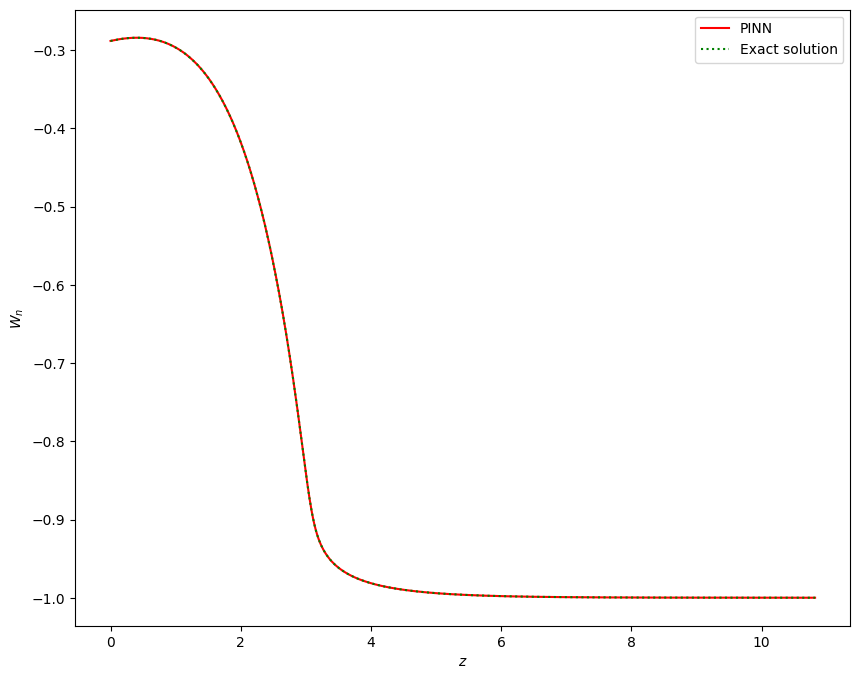

In [11]:
best_C, w_relic = training(n_epochs, C)

### Best C and observed wield prediction

In [12]:
print(best_C)

29.203707087110214


In [13]:
print(w_relic)

-26.15850257873535
